# Session 5 — Demo 1 — Drawing a line

**What this demo covers.** The first tool of machine learning is older than any of us: a straight line through a cloud of points. We draw it by eye and find out what makes one line better than another. Then Python fits the best one, and we read it the way an economist reads a regression: coefficients, p-values, R². Then the two classic traps, scale and twins, on data you already know.

**Data.** The ALPHA warehouse week — [data dictionary](../../data/README.md). Two small **made-up tables** appear along the way, always named `toy_…` and marked 🧪, so you can check a method by eye before trusting it on real data.

**How to run.** Locally: top to bottom. Colab: uncomment the two `git clone` lines in the setup cell. Needs `statsmodels`, preinstalled in Colab.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import AutoMinorLocator

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib statsmodels

POINT_COLOR = "#4a7ebb"
LINE_COLOR = "#c0392b"

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

---

## 1. The table we already know

For four weeks we described the warehouse and tested ideas about it. Tonight we **predict**: *how long will the next task take?* Session 1 drew a ladder of three questions: *what happened?*, *why?*, *what will happen?* Its example for the top step was exactly this one.

We need last week's per-task table: one row per finished task, with its duration in minutes and its number of successful picks. This is the code from session 4, unchanged.

In [3]:
events = pd.read_parquet(DATA / "picking_events.parquet")

picks = events[events["event_type"] == "PickCorrectItem"]
finished_ids = set(events.loc[events["event_type"] == "FinishTask", "task_id"])

tasks = (
    events
    .groupby("task_id")
    .agg(
        start=("event_time", "min"),
        end=("event_time", "max"),
    )
)
tasks["picks"] = picks.groupby("task_id").size()
tasks["picks"] = tasks["picks"].fillna(0).astype(int)
tasks["finished"] = tasks.index.isin(finished_ids)

tasks = tasks[tasks["finished"] & (tasks["picks"] > 0)]
tasks["duration_min"] = (tasks["end"] - tasks["start"]).dt.total_seconds() / 60
tasks[["picks", "duration_min"]].head(3)

,picks,duration_min
task_id,,
800000001,12,11.168150
800000002,16,8.555833
800000003,46,29.825983


In [4]:
print(f"finished tasks with at least one pick: {len(tasks):,}")

finished tasks with at least one pick: 4,077


## 2. The cloud

One dot per task: how many picks it had, and how many minutes it took.

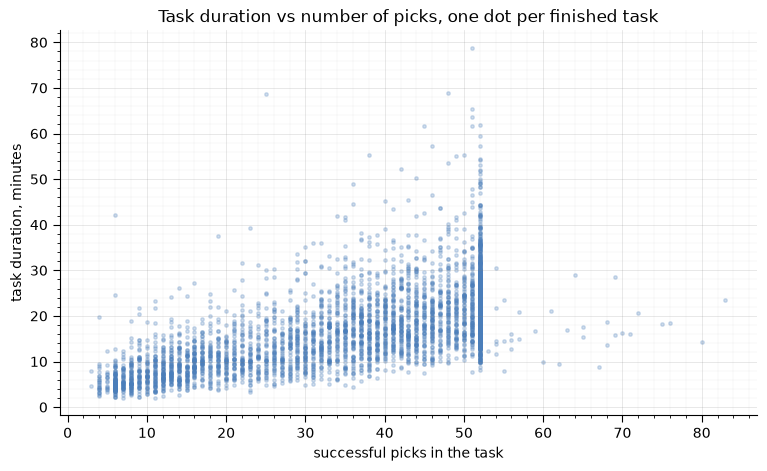

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    tasks["picks"],
    tasks["duration_min"],
    s=6,
    alpha=0.25,
    color=POINT_COLOR,
)
ax.set_title("Task duration vs number of picks, one dot per finished task")
ax.set_xlabel("successful picks in the task")
ax.set_ylabel("task duration, minutes")
make_ax_better(ax, minor="xy")
plt.show()

More picks, more minutes, but with a lot of scatter around that trend. The vertical wall at 52 is real: the warehouse system cuts orders into tasks of at most 52 picks, so about one task in five has exactly 52. The cap doesn't apply to every kind of task: 34 tasks, under 1%, are bigger, up to 83 picks.

**Pause.** If you had to draw *one straight line* through this cloud, where would it go? Where does it cross zero picks? How steep is it?

Here are two lines drawn by hand. A straight line is always *start + slope × picks*: the start is where it crosses zero picks, the slope is how many minutes each extra pick adds.

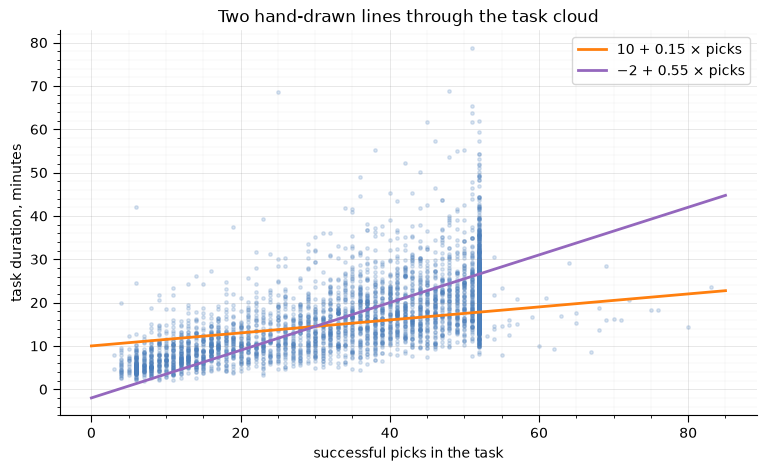

In [6]:
# two lines chosen by eye: start (minutes) + slope (minutes per pick) * picks
line_ends = np.array([0, 85])
too_flat = 10 + 0.15 * line_ends
too_steep = -2 + 0.55 * line_ends

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    tasks["picks"],
    tasks["duration_min"],
    s=6,
    alpha=0.2,
    color=POINT_COLOR,
)
ax.plot(
    line_ends,
    too_flat,
    color="tab:orange",
    linewidth=2,
    label="10 + 0.15 × picks",
)
ax.plot(
    line_ends,
    too_steep,
    color="tab:purple",
    linewidth=2,
    label="−2 + 0.55 × picks",
)
ax.set_title("Two hand-drawn lines through the task cloud")
ax.set_xlabel("successful picks in the task")
ax.set_ylabel("task duration, minutes")
ax.legend()
make_ax_better(ax, minor="xy")
plt.show()

Both look wrong, but *why* exactly? We need a rule that says which line is better, and then a way to find the best one. First, the words for what we are building.

## 3. Our first model: the words and the formula

A **model** is a formula with blanks. Filling the blanks from data is called **fitting**, and the result is a **fitted model** that can make guesses. The same two steps work for every model in this course, from tonight's line to next hour's boosting:

```
 fit:      X (features)  +  y (target)   ──▶  fitted model  (the blanks filled in)
 predict:  X_new (features of new cases)  ──▶  fitted model  ──▶  ŷ (the guesses)
```

- **target `y`**: the column we want to guess. Here: task duration in minutes.
- **features `X`**: the columns the model may read. Here: the number of picks. Capital `X`, because there can be many columns; small `y`, because there is one target.
- **`ŷ`** ("y-hat"): the model's guess for `y`. The hat means "estimated".

Tonight's model is the straight line. For task number *i*:

$$\hat y_i = \beta_0 + \beta_1 x_i$$

where $x_i$ is the task's picks, $\beta_0$ is the start (minutes at zero picks) and $\beta_1$ is the slope (minutes per pick). $\beta_0$ and $\beta_1$ are the blanks; they are called **coefficients**.

**What makes one line better than another.** For each task the **error** is the distance from the real value to the guess: $e_i = y_i - \hat y_i$. Adding errors doesn't work, because pluses and minuses cancel. So we square them and add them up. **Ordinary least squares (OLS)** picks the coefficients that make that sum as small as possible:

$$\text{OLS: choose } \beta_0, \beta_1 \text{ to minimise } \sum_i \left(y_i - \beta_0 - \beta_1 x_i\right)^2$$

Squaring keeps every error positive, and it makes big misses count a lot more than small ones.

## 4. 🧪 Toy example: least squares on five made-up tasks

Not sure how a method works? Build a table of five rows where you can check everything by eye. These five tasks are **made up**; everything named `toy_…` in this section belongs to them.

In [7]:
toy_tasks = pd.DataFrame({
    "picks": [10, 20, 30, 40, 50],
    "minutes": [9, 10, 17, 16, 24],
})
toy_tasks

,picks,minutes
0,10,9
1,20,10
2,30,17
3,40,16
4,50,24


Take the "too flat" line, `10 + 0.15 × picks`. For each task it makes a guess $\hat y$, and the error is real minus guess. We build the table one column at a time.

In [8]:
toy_tasks["flat_guess"] = 10 + 0.15 * toy_tasks["picks"]
toy_tasks["flat_error"] = toy_tasks["minutes"] - toy_tasks["flat_guess"]
toy_tasks

,picks,minutes,flat_guess,flat_error
0,10,9,11.5,-2.5
1,20,10,13.0,-3.0
2,30,17,14.5,2.5
3,40,16,16.0,0.0
4,50,24,17.5,6.5


Square each error and add them up:

In [9]:
toy_tasks["flat_error_squared"] = toy_tasks["flat_error"] ** 2
toy_flat_total = toy_tasks["flat_error_squared"].sum()
print(f"sum of squared errors, flat line: {toy_flat_total:.1f}")
toy_tasks

sum of squared errors, flat line: 63.8


,picks,minutes,flat_guess,flat_error,flat_error_squared
0,10,9,11.5,-2.5,6.25
1,20,10,13.0,-3.0,9.00
2,30,17,14.5,2.5,6.25
3,40,16,16.0,0.0,0.00
4,50,24,17.5,6.5,42.25


Now let OLS find the best line. The standard tool is `statsmodels`: every econometrics paper and every bank's model documentation shows its tables. It follows the schema from section 3 literally:

1. `sm.add_constant(features)` adds a column of ones called `const`. **statsmodels fits exactly the columns you give it**, and the column of ones is what gives the line its start $\beta_0$. Forget it, and the line is forced through zero (we'll see that in a minute).
2. `sm.OLS(y, X)` is the **model**: the formula with blanks. Nothing is computed yet. Note the order: **target first**, features second. Later tonight scikit-learn takes them the other way round, `.fit(X, y)`. Every library has its habit; read the order from its documentation, not from memory.
3. `.fit()` fills the blanks and returns the **fitted model**. Its `.params` are the coefficients.
4. `.predict(X)` makes the guesses $\hat y$.

In [10]:
toy_X = sm.add_constant(toy_tasks[["picks"]])
toy_y = toy_tasks["minutes"]
toy_X

,const,picks
0,1.0,10
1,1.0,20
2,1.0,30
3,1.0,40
4,1.0,50


In [11]:
toy_model = sm.OLS(toy_y, toy_X)   # the model: a formula with blanks
toy_fitted = toy_model.fit()       # the fitted model: blanks filled in
toy_fitted.params

const    4.40
picks    0.36
dtype: float64

In [12]:
toy_tasks["best_guess"] = toy_fitted.predict(toy_X)
toy_tasks["best_error"] = toy_tasks["minutes"] - toy_tasks["best_guess"]
toy_best_total = (toy_tasks["best_error"] ** 2).sum()

print(
    f"best line: {toy_fitted.params['const']:.2f} "
    f"+ {toy_fitted.params['picks']:.2f} × picks\n"
    f"sum of squared errors: flat line {toy_flat_total:.1f}, "
    f"best line {toy_best_total:.1f}"
)

best line: 4.40 + 0.36 × picks
sum of squared errors: flat line 63.8, best line 17.2


**What happens without `add_constant`.** The model then has only a slope, so the line must pass through zero minutes at zero picks:

In [13]:
toy_through_zero = sm.OLS(toy_y, toy_tasks[["picks"]]).fit()
toy_zero_squared_errors = (toy_y - toy_through_zero.predict(toy_tasks[["picks"]])) ** 2

print(
    f"without the constant: {toy_through_zero.params['picks']:.2f} × picks, "
    f"no start at all\n"
    f"sum of squared errors: {toy_zero_squared_errors.sum():.1f} "
    f"(with the constant: {toy_best_total:.1f})"
)

without the constant: 0.48 × picks, no start at all
sum of squared errors: 34.8 (with the constant: 17.2)


No error message, just a worse line with a different slope. This is the most common `statsmodels` mistake, so the habit is: **always `sm.add_constant`, and check that `const` appears in the coefficients.**

The comparison as a picture. Every grey stick is one error: the distance from a dot to its line. Least squares makes the sticks as short as possible, counted in squares. `ax.vlines(x, from, to)` draws one vertical stick per point, and `fig.suptitle` puts one title over both panels.

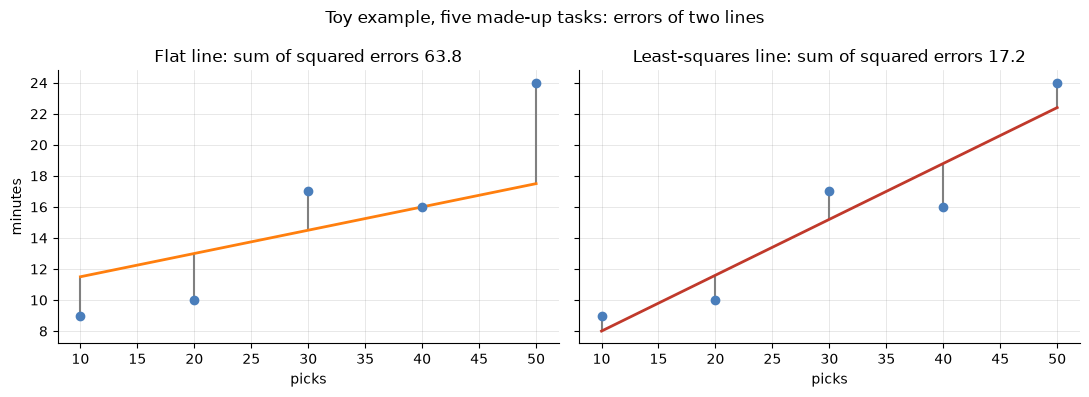

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    sharey=True,
)

axes[0].vlines(
    toy_tasks["picks"],
    toy_tasks["flat_guess"],
    toy_tasks["minutes"],
    color="grey",
)
axes[0].plot(
    toy_tasks["picks"],
    toy_tasks["flat_guess"],
    color="tab:orange",
    linewidth=2,
)
axes[0].set_title(f"Flat line: sum of squared errors {toy_flat_total:.1f}")

axes[1].vlines(
    toy_tasks["picks"],
    toy_tasks["best_guess"],
    toy_tasks["minutes"],
    color="grey",
)
axes[1].plot(
    toy_tasks["picks"],
    toy_tasks["best_guess"],
    color=LINE_COLOR,
    linewidth=2,
)
axes[1].set_title(f"Least-squares line: sum of squared errors {toy_best_total:.1f}")

for ax in axes:
    ax.scatter(
        toy_tasks["picks"],
        toy_tasks["minutes"],
        color=POINT_COLOR,
        zorder=3,
    )
    ax.set_xlabel("picks")
    make_ax_better(ax)
axes[0].set_ylabel("minutes")
fig.suptitle("Toy example, five made-up tasks: errors of two lines")
plt.tight_layout()
plt.show()

## 5. Back to the real data: the best line through 4,077 tasks

The same four steps on the real tasks. `X` holds the features (picks, plus the column of ones), `y` the target.

In [15]:
X_picks = sm.add_constant(tasks[["picks"]])
y = tasks["duration_min"]

picks_model = sm.OLS(y, X_picks).fit()
print(
    f"duration = {picks_model.params['const']:.2f} min "
    f"+ {picks_model.params['picks']:.3f} min × picks\n"
    f"one pick adds about {picks_model.params['picks'] * 60:.0f} seconds"
)

duration = 4.32 min + 0.358 min × picks
one pick adds about 22 seconds


Read it aloud like a business sentence: **every task costs about 4.3 minutes before the first pick** (walking to the zone, starting up, finishing off), **and each pick adds about 0.36 minutes, roughly 22 seconds.**

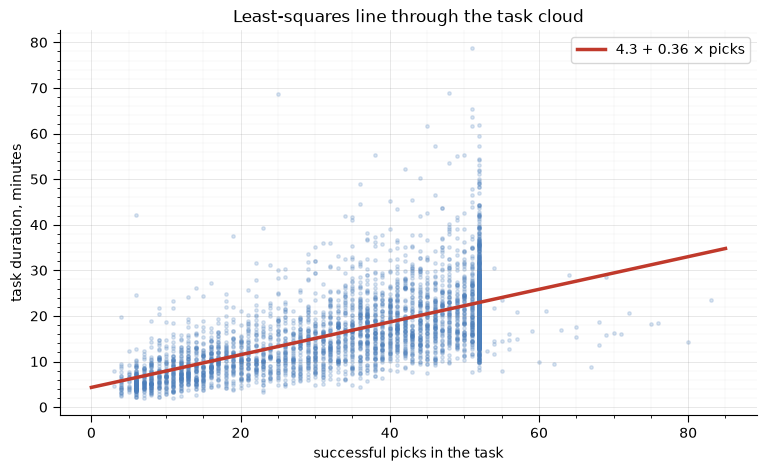

In [16]:
line_ends = np.array([0, 85])
line_start = picks_model.params["const"]
line_slope = picks_model.params["picks"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    tasks["picks"],
    tasks["duration_min"],
    s=6,
    alpha=0.2,
    color=POINT_COLOR,
)
ax.plot(
    line_ends,
    line_start + line_slope * line_ends,
    color=LINE_COLOR,
    linewidth=2.5,
    label=f"{line_start:.1f} + {line_slope:.2f} × picks",
)
ax.set_title("Least-squares line through the task cloud")
ax.set_xlabel("successful picks in the task")
ax.set_ylabel("task duration, minutes")
ax.legend()
make_ax_better(ax, minor="xy")
plt.show()

**How good is the line?** Two numbers.

**Average miss** (mean absolute error): drop the sign of every error and average. "On average, the line is off by N minutes."

$$\text{average miss} = \frac{1}{n}\sum_i \left|y_i - \hat y_i\right|$$

**R²** compares the line with the laziest possible model, which guesses the *average duration* $\bar y$ for every task:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$$

The bottom of the fraction is the total spread of task durations. Divide it by $n$ and you get the **variance**: the average squared distance from the mean. The std from session 3 is its square root, which is why the std is in minutes and the variance in minutes squared. The top is the spread that is *left* after the line. So **R² is the share of the variance of `y` that the line explains**: 0 = no better than the average, 1 = every dot exactly on the line. With one feature there is a shortcut: R² equals the square of the correlation from session 3. A fitted `statsmodels` model keeps its R² in `.rsquared`.

In [17]:
tasks["line_guess"] = picks_model.predict(X_picks)
tasks["line_error"] = tasks["duration_min"] - tasks["line_guess"]

average_miss = tasks["line_error"].abs().mean()

left_after_line = (tasks["line_error"] ** 2).sum()
total_spread = ((tasks["duration_min"] - tasks["duration_min"].mean()) ** 2).sum()
r_squared = 1 - left_after_line / total_spread

print(
    f"average miss: {average_miss:.1f} minutes\n"
    f"R² by the formula:        {r_squared:.3f}\n"
    f"R² from statsmodels:      {picks_model.rsquared:.3f}\n"
    f"correlation squared:      {tasks['picks'].corr(tasks['duration_min']) ** 2:.3f}"
)

average miss: 4.9 minutes
R² by the formula:        0.400
R² from statsmodels:      0.400
correlation squared:      0.400


Picks explain **40%** of the variance of task time, and a typical guess is off by about **5 minutes** on a task of 17. Useful for planning a shift, not precise enough to promise a customer a minute.

## 6. Is the slope real? Significance

Last week's question comes back: could a slope like 0.36 appear by luck, in a world where picks don't affect duration at all? That is exactly what the **p-value of a coefficient** answers. `.summary()` prints the full table:

In [18]:
print(picks_model.summary())

                            OLS Regression Results                            
Dep. Variable:           duration_min   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     2719.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:45:13   Log-Likelihood:                -13618.
No. Observations:                4077   AIC:                         2.724e+04
Df Residuals:                    4075   BIC:                         2.725e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3249      0.264     16.402      0.0

A big table; you need five things from it.

| where | what it says here |
|---|---|
| `coef` | the line: `const` 4.33 is the start $\beta_0$, `picks` 0.358 is the slope $\beta_1$ |
| `std err` | how much the coefficient would wobble on another week of data |
| `P>\|t\|` | the p-value: the chance of a slope this steep in a world where picks don't matter. `0.000` means smaller than 0.0005, as in session 4 |
| `[0.025 0.975]` | the range where the true slope most likely sits: 0.35 to 0.37 minutes per pick |
| `R-squared` | 0.40, as we computed by hand |

The rest of the table (`AIC`, `Durbin-Watson`, …) is for another course.

From here on we want only the coefficients and their p-values. A small function prints them as a compact table; `.params` holds the coefficients, `.pvalues` the p-values, `.rsquared` the R².

In [19]:
def summarize_coefficients(model):
    """Coefficient and p-value per feature of a fitted statsmodels model."""
    return pd.DataFrame({
        "coefficient": model.params.round(4),
        "p_value": model.pvalues.round(4),
    })


summarize_coefficients(picks_model)

,coefficient,p_value
const,4.3249,0.0
picks,0.3584,0.0


**More than one feature.** The formula simply grows, one coefficient per feature:

$$\hat y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots$$

Each coefficient now says how much *that* feature adds **while the others stay the same**. Wrong scans cost time: a picker scans the wrong item and has to go back. Let's count them per task and add them.

In [20]:
wrong_scans = events[events["event_type"] == "PickWrongItem"]
tasks["wrong_scans"] = wrong_scans.groupby("task_id").size()
tasks["wrong_scans"] = tasks["wrong_scans"].fillna(0).astype(int)
tasks[["picks", "wrong_scans", "duration_min"]].head(3)

,picks,wrong_scans,duration_min
task_id,,,
800000001,12,2,11.168150
800000002,16,5,8.555833
800000003,46,14,29.825983


In [21]:
X_picks_scans = sm.add_constant(tasks[["picks", "wrong_scans"]])
scans_model = sm.OLS(y, X_picks_scans).fit()

print(f"R²: {picks_model.rsquared:.2f} → {scans_model.rsquared:.2f}")
summarize_coefficients(scans_model)

R²: 0.40 → 0.44


,coefficient,p_value
const,4.3098,0.0
picks,0.2991,0.0
wrong_scans,0.2616,0.0


**Each wrong scan costs about 0.26 minutes, around 16 seconds**, on top of the picks, and the p-value says this is no accident. R² grows from 0.40 to 0.44. That is a sentence a warehouse manager can act on: fewer wrong scans, shorter tasks.

**Significant is not the same as big.** A p-value shrinks as the data grows. With 4,077 tasks, even a small effect gets a p-value too small to print; with 50,000 rows almost every feature does. So read two numbers, not one. The p-value says the effect is not zero. The coefficient says whether it is big enough to care about. Here 16 seconds per wrong scan passes both tests.

Look at picks too: **0.36 → 0.30**. Bigger tasks also have more wrong scans, so the first line credited picks with part of the scans' cost. Hold that thought: section 8 is about exactly this.

## 7. Trap 1: scale

Heavier tasks should take longer. Let's add the total weight of the items picked in each task. Weight per item sits in `ovh.parquet`; one join, then a sum per task.

In [22]:
ovh = pd.read_parquet(DATA / "ovh.parquet")

picks_with_ovh = picks.merge(ovh, on="item_id", how="left")
print(
    f"picks: {len(picks):,}   after the join: {len(picks_with_ovh):,}   "
    f"without weight: {picks_with_ovh['weight'].isna().sum():,}"
)

tasks["kg"] = picks_with_ovh.groupby("task_id")["weight"].sum()
tasks["litres"] = picks_with_ovh.groupby("task_id")["volumeliter"].sum()
tasks[["picks", "kg", "litres", "duration_min"]].head(3)

picks: 145,904   after the join: 145,904   without weight: 0


,picks,kg,litres,duration_min
task_id,,,,
800000001,12,3.964,20.434,11.168150
800000002,16,10.977,35.399,8.555833
800000003,46,17.567,136.751,29.825983


The picks model with weight and volume added (wrong scans left out, to keep the table small):

In [23]:
X_kg = sm.add_constant(tasks[["picks", "kg", "litres"]])
kg_model = sm.OLS(tasks["duration_min"], X_kg).fit()
summarize_coefficients(kg_model)

,coefficient,p_value
const,4.2607,0.0000
picks,0.3300,0.0000
kg,-0.0398,0.0011
litres,0.0232,0.0000


Put the weight in **grams** instead of kilograms and fit again. Nothing about the tasks changes, only the unit.

In [24]:
tasks["grams"] = tasks["kg"] * 1000

X_grams = sm.add_constant(tasks[["picks", "grams", "litres"]])
grams_model = sm.OLS(tasks["duration_min"], X_grams).fit()
print(
    f"weight coefficient in kg:    {kg_model.params['kg']:.5f}\n"
    f"weight coefficient in grams: {grams_model.params['grams']:.8f}\n"
    f"p-value, both times:          {kg_model.pvalues['kg']:.4f}"
)

weight coefficient in kg:    -0.03976
weight coefficient in grams: -0.00003976
p-value, both times:          0.0011


The coefficient shrinks a thousand times; the p-value and the model don't move at all. **A small coefficient does not mean an unimportant feature.** A coefficient is "minutes per one unit", and units differ: one pick, one kilogram, one litre are not comparable steps.

**The cure: put every feature on one ruler.** Rewrite each column as "how many standard deviations above or below the average task", using the mean and std from session 3. This is also called a **z-score** (remember the name: it comes back in Demo 2 with a different meaning).

In [25]:
feature_names = ["picks", "kg", "litres"]
X_standardized = (
    (tasks[feature_names] - tasks[feature_names].mean())
    / tasks[feature_names].std()
)
X_standardized.head(3)

,picks,kg,litres
task_id,,,
800000001,-1.481619,-1.020255,-1.173043
800000002,-1.224648,-0.456407,-0.846563
800000003,0.702637,0.073431,1.364558


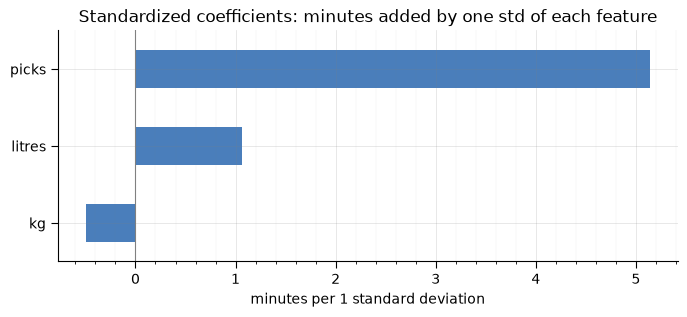

kg       -0.49
litres    1.06
picks     5.14
dtype: float64


In [26]:
standardized_model = sm.OLS(
    tasks["duration_min"],
    sm.add_constant(X_standardized),
).fit()
minutes_per_std = standardized_model.params.drop("const").sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
minutes_per_std.plot(kind="barh", ax=ax, color=POINT_COLOR)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Standardized coefficients: minutes added by one std of each feature")
ax.set_xlabel("minutes per 1 standard deviation")
ax.set_ylabel("")
make_ax_better(ax, minor="x")
plt.show()

print(minutes_per_std.round(2))

Now the bars compare honestly. One std of picks (about 16 picks) adds **5.1 minutes**; volume adds about 1; weight… *takes away* half a minute?

## 8. Trap 2: twins

Weight on its own tells a different story:

In [27]:
kg_alone = sm.OLS(tasks["duration_min"], sm.add_constant(tasks[["kg"]])).fit()

print(
    f"weight alone:             {kg_alone.params['kg']:+.3f} min per kg\n"
    f"weight next to picks:     {kg_model.params['kg']:+.3f} min per kg"
)

weight alone:             +0.271 min per kg
weight next to picks:     -0.040 min per kg


Alone, heavier tasks take longer, as anyone would expect. Next to picks, "heavier is faster"?! Look at how the features move together:

In [28]:
tasks[["picks", "kg", "litres"]].corr().round(2)

,picks,kg,litres
picks,1.00,0.61,0.70
kg,0.61,1.00,0.69
litres,0.70,0.69,1.00


A task with more picks also weighs more and takes more space: correlations of 0.61 and 0.70. The three columns carry much of the same news. When features are **twins**, the model has to split the credit between them, and one coefficient can land on the wrong side. The prediction is still fine; the *reading* of single coefficients is not. Look back at weight's p-value next to picks: 0.001. The flipped sign passed the significance test. A small p-value says the coefficient isn't zero, not that its sign means what you think. Wrong scans and picks are relatives too, only milder (correlation 0.45): that is why picks lost part of their credit in section 6.

⏭ **The extreme case.** Add a **made-up** column that is almost a copy of `picks` (twice the picks plus a little noise), and watch the p-values.

In [29]:
rng = np.random.default_rng(0)
tasks["picks_near_copy"] = tasks["picks"] * 2 + rng.normal(0, 0.5, len(tasks))

twins_model = sm.OLS(
    tasks["duration_min"],
    sm.add_constant(tasks[["picks", "picks_near_copy"]]),
).fit()
summarize_coefficients(twins_model)

,coefficient,p_value
const,4.3239,0.0000
picks,0.4613,0.2822
picks_near_copy,-0.0514,0.8104


Both twins look **insignificant** (p = 0.28 and 0.81), although picks on their own had a p-value too small to print. Neither twin can prove it matters, because the other one could do the same job. The model hasn't become worse at predicting; it has become impossible to read.

**The cure:** look at the correlations *before* the model, and from each pair of twins keep one, the one that is easier to explain.

## 9. ⏭ When can you trust the p-values? Gauss–Markov

The table's p-values rely on five conditions, known as the Gauss–Markov assumptions:

| condition | in plain words | if it breaks |
|---|---|---|
| linearity | the true relationship is a straight line | the line itself is wrong: prediction suffers (Demo 3) |
| no hidden driver | the errors average zero whatever the features are | coefficients are biased: they mix in something you didn't include |
| equal spread | errors are about as big for small tasks as for big ones | p-values are off; coefficients are fine |
| independent errors | one task's error tells nothing about the next | p-values are off; coefficients are fine |
| no exact twins | no feature is an exact copy of others | no unique answer: statsmodels still prints coefficients, but they are one arbitrary split among endless equally good ones (section 8 was the near version) |

Let's check **equal spread** on our first line. Here are the errors against the number of picks:

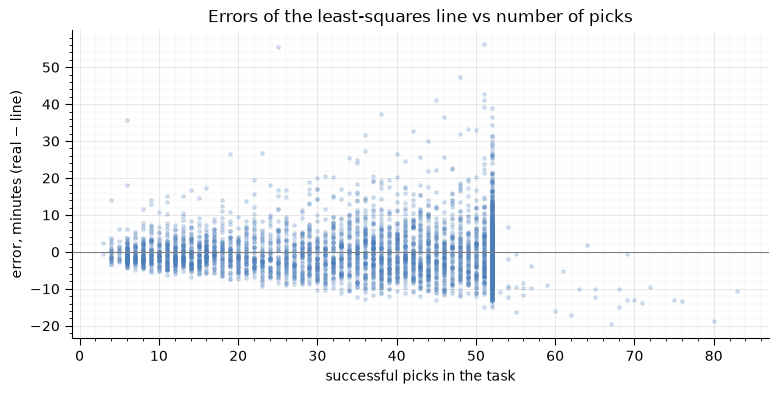

error spread (std, minutes) by task size:
picks
(0, 20]     3.8
(20, 40]    6.5
(40, 60]    8.1
(60, 90]    5.6
Name: line_error, dtype: float64


In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    tasks["picks"],
    tasks["line_error"],
    s=6,
    alpha=0.2,
    color=POINT_COLOR,
)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Errors of the least-squares line vs number of picks")
ax.set_xlabel("successful picks in the task")
ax.set_ylabel("error, minutes (real − line)")
make_ax_better(ax, minor="xy")
plt.show()

error_spread = (
    tasks
    .groupby(pd.cut(tasks["picks"], [0, 20, 40, 60, 90]), observed=True)["line_error"]
    .std()
    .round(1)
)
print("error spread (std, minutes) by task size:")
print(error_spread)

The cloud of errors opens like a funnel: from about 4 minutes on tasks of up to 20 picks to about 8 on tasks of 40–60. (Tasks above 60 picks are too few to judge.) **Equal spread is broken**, so the p-values above are approximate.

That is normal, and it has a standard fix: *robust standard errors*, one extra argument in `.fit()`. `cov_type="HC3"` is the most common robust recipe; you don't need the others. The coefficients stay the same; only the `std err` column, and the p-values built from it, are recomputed without the equal-spread assumption. `.bse` holds that column, so we put the usual and the robust ones side by side.

In [31]:
robust_model = sm.OLS(y, X_picks_scans).fit(cov_type="HC3")

std_errors = pd.DataFrame({
    "usual": scans_model.bse.round(4),
    "robust": robust_model.bse.round(4),
})
std_errors

,usual,robust
const,0.2541,0.1851
picks,0.0074,0.0072
wrong_scans,0.0147,0.0192


The robust std error of wrong scans is bigger, 0.015 → 0.019: the old table was a little too sure of itself. But the coefficient is still more than ten std errors away from zero, so its p-value stays far below 0.0005 (`summarize_coefficients(robust_model)` still prints 0.0). Our conclusions survive. The habit is what matters: **name the broken assumption and check whether the conclusion survives it.**

## Try it yourself

1. Add `litres` to the picks-and-scans model. Does it stay significant next to picks? Why might it?
2. Fit duration on `kg` alone, then on `litres` alone. Which one looks more important, and does standardizing change your answer?
3. Take `scans_model` and predict a task with 60 picks and 2 wrong scans. Build the task as a one-row table with the same columns as the model, then add the constant with `sm.add_constant(new_task, has_constant="add")`: with a single row every column looks constant, so statsmodels skips `const` unless you insist. Check that `const` is there. How far from reality would you expect that guess to be?

In [32]:
# your turn

## Recap

- **Regression = the best line through points.** "Best" means the smallest sum of squared errors: least squares.
- Read the line as a business sentence: 4.3 minutes per task plus 0.36 minutes per pick.
- Judge it with plain numbers: an average miss of 4.9 minutes, R² 0.40.
- **Significance:** the p-value of a coefficient asks "could this slope be luck?". Wrong scans cost about 16 seconds each, and that is no accident.
- **Trap 1, scale:** a coefficient is "per unit"; standardize before comparing features.
- **Trap 2, twins:** correlated features split the credit, and signs and p-values stop being readable. Check correlations first and keep one twin.
- The p-values rest on assumptions; equal spread is broken here, and robust standard errors confirm the conclusions.

---

## ⚡ Extras — power tools, not required

**`numpy.polyfit`** fits the same least-squares line in one call, and with `deg=2` a curve. Useful for a quick look; for reading coefficients and p-values, `statsmodels` is the tool.

In [33]:
slope, intercept = np.polyfit(tasks["picks"], tasks["duration_min"], deg=1)
print(f"polyfit: {intercept:.2f} + {slope:.3f} × picks")

polyfit: 4.32 + 0.358 × picks
